# Applications of Principal Component Analysis (PCA)

### Use PCA to project 2D data onto its principle axes
### Use PCA for feature space dimensionality reduction
### Relate explained variance to feature importance and noise reduction

<h2 style="color: yellow">Part I: Using PCA to project 2-D data onto its principle axes</h2>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

In [2]:
# create 2D dataset containing two linearly correlated features
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2], [2, 2]]
x = np.random.multivariate_normal(mean = mean, cov = cov, size = 200)

<h3 style = 'color: red'>Exercise 1: Visualize the relationship between the two features</h3>

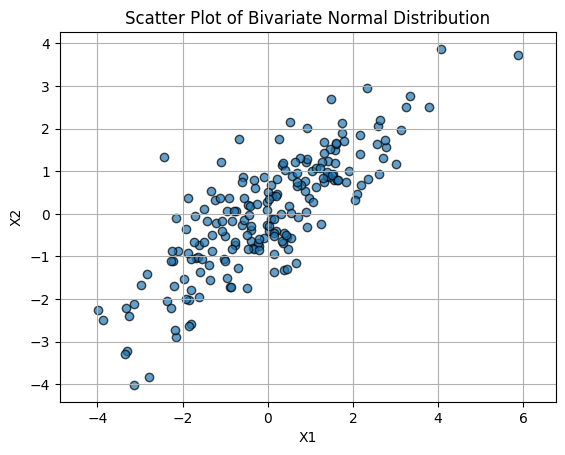

In [6]:
plt.figure()
plt.scatter(x[:, 0], x[:, 1], ec = 'k', alpha = 0.7)
plt.title('Scatter Plot of Bivariate Normal Distribution')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axis('equal')
plt.grid(True)
plt.show()

<h3 style = 'color: red'>Perform PCA on the dataset</h3>

In [7]:
pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x)

<h3 style = 'color: red'>Get the princial components from the model</h3>

In [8]:
components = pca.components_
components

array([[ 0.78215821,  0.62307987],
       [-0.62307987,  0.78215821]])

In [9]:
pca.explained_variance_ratio_

array([0.9111946, 0.0888054])

<h3 style = 'color: red'>Project the data onto its principal components axes</h3>

In [10]:
# np.dot do the inner product (project data points onto the axis you designated)
# projection_pc1 means put original data points and project them onto new PC1 axis
projection_pc1 = np.dot(x, components[0])
projection_pc2 = np.dot(x, components[1])

In [11]:
x_pc1 = projection_pc1 * components[0][0]
y_pc1 = projection_pc1 * components[0][1]
x_pc2 = projection_pc2 * components[1][0]
y_pc2 = projection_pc2 * components[1][1]

C:\Users\Sammi Wang\AppData\Local\Temp\ipykernel_28028\3305790760.py:5: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x_pc1, y_pc1, c = 'r', ec = 'k', marker = 'x', s = 70, alpha = 0.5, label = 'Projection onto PC 1')
C:\Users\Sammi Wang\AppData\Local\Temp\ipykernel_28028\3305790760.py:6: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x_pc2, y_pc2, c = 'b', ec = 'k', marker = 'x', s = 70, alpha = 0.5, label = 'Projection onto PC 2')


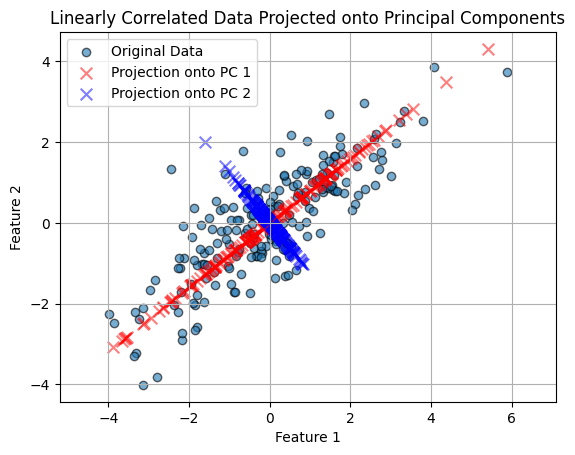

In [12]:
# plot original data
plt.figure()
plt.scatter(x[:, 0], x[:, 1], label = 'Original Data', ec = 'k', alpha = 0.6)
# plot the projection along PC1 and PC2
plt.scatter(x_pc1, y_pc1, c = 'r', ec = 'k', marker = 'x', s = 70, alpha = 0.5, label = 'Projection onto PC 1')
plt.scatter(x_pc2, y_pc2, c = 'b', ec = 'k', marker = 'x', s = 70, alpha = 0.5, label = 'Projection onto PC 2')
plt.title('Linearly Correlated Data Projected onto Principal Components')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

<h2 style="color: yellow">Part II: PCA for feature space dimensionality reduction</h2>

### Use PCA to project the four-dimensional Iris feature data set down onto a 2-dimensional feature space

In [16]:
# load the iris dataset, which is embedded inside sklearn datasets
iris = datasets.load_iris()
x = iris.data
y = iris.target
target_names = iris.target_names
# standarize the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

<h3 style = 'color: red'>Initiate a PCA model and reduce the iris data set dimensionality to two components</h3>

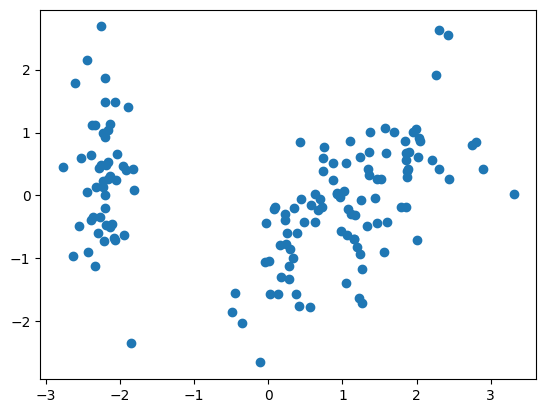

In [19]:
pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scaled)
plt.scatter(x_pca[:, 0], x_pca[:, 1])

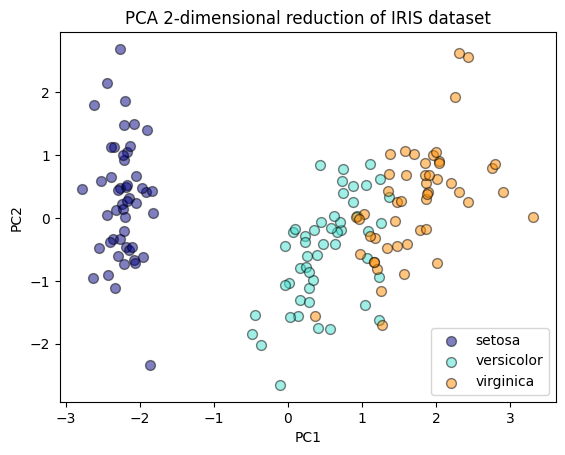

In [20]:
# plot the PCA-transformed data in 2D
plt.figure()
colors = ['navy', 'turquoise', 'darkorange']
lw = 1
for color, i, target_name in zip(colors, range(3), target_names):
    plt.scatter(x_pca[y == i, 0], x_pca[y == i, 1], color = color, s = 50, ec = 'k', alpha = 0.5, lw = lw, label = target_name)
plt.title('PCA 2-dimensional reduction of IRIS dataset')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(loc = 'best', shadow = False, scatterpoints = 1)
plt.show()

In [21]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

In [22]:
pca.components_

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199]])

<h3 style = 'color: red'>Reinitialize the PCA model without reducing the dimension</h3>

In [28]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
# apply pca
pca = PCA()
x_pca = pca.fit_transform(x_scaled)
x_pca

array([[-2.26470281e+00,  4.80026597e-01,  1.27706022e-01,
        -2.41682039e-02],
       [-2.08096115e+00, -6.74133557e-01,  2.34608854e-01,
        -1.03006775e-01],
       [-2.36422905e+00, -3.41908024e-01, -4.42014848e-02,
        -2.83770534e-02],
       [-2.29938422e+00, -5.97394508e-01, -9.12901063e-02,
         6.59555596e-02],
       [-2.38984217e+00,  6.46835383e-01, -1.57381957e-02,
         3.59228133e-02],
       [-2.07563095e+00,  1.48917752e+00, -2.69682944e-02,
        -6.60818022e-03],
       [-2.44402884e+00,  4.76441976e-02, -3.35470401e-01,
         3.67755572e-02],
       [-2.23284716e+00,  2.23148073e-01,  8.86954979e-02,
         2.46120962e-02],
       [-2.33464048e+00, -1.11532768e+00, -1.45076864e-01,
         2.68592208e-02],
       [-2.18432817e+00, -4.69013561e-01,  2.53765567e-01,
         3.98992877e-02],
       [-2.16631010e+00,  1.04369065e+00,  2.68681102e-01,
        -1.67313672e-02],
       [-2.32613087e+00,  1.33078335e-01, -9.37592444e-02,
      

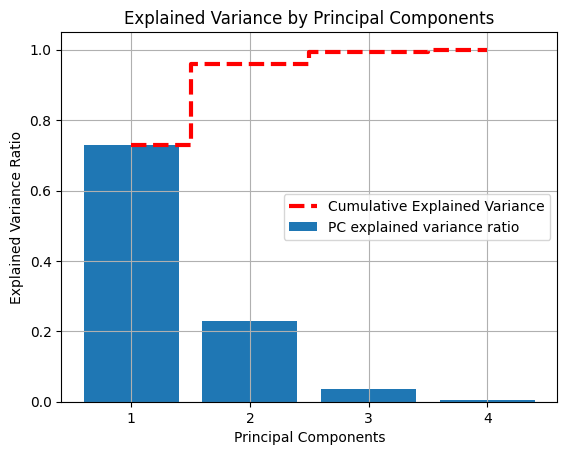

In [33]:
# explained variance ratio
ratio = pca.explained_variance_ratio_
# plot explained variance ratio for each components
plt.figure()
plt.bar(x = range(1, len(ratio) + 1), height = ratio, alpha = 1, align = 'center', label = 'PC explained variance ratio')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance by Principal Components')
# plot cumulative explained variance
cumulative_variance = np.cumsum(ratio)
plt.step(range(1, 5), cumulative_variance, where = 'mid', linestyle = '--', lw = 3, color = 'red', label = 'Cumulative Explained Variance')
# only display integer ticks on the x-axis
plt.xticks(range(1, 5))
plt.legend()
plt.grid(True)
plt.show()